# Simulación del Modelo de Ising 2D mediante el Algoritmo de Metrópolis

**Autor:** Alberto Jiménez Cañadillas

En este trabajo he realizado una simulación numérica de un sistema ferromagnético bidimensional. El objetivo es estudiar cómo varía el orden del sistema (la magnetización) al cambiar la temperatura y localizar la temperatura crítica de transición de fase.

Para el motor de la simulación he programado el código en **C++** (archivo `Ising.cpp`), y para la visualización de datos y animaciones he utilizado **Python**. Todo el desarrollo se ha llevado a cabo en **VSCode** sobre una máquina virtual con **Ubuntu**. Para la estructura del código y la redacción de este informe me he apoyado en herramientas de IA como **Gemini** y **Copilot**, asegurándome de que la lógica física y los resultados concuerden con la teoría, en particular que la programación sea toda en C++ y no incluya C.

## 1. Análisis Visual y Temperatura Crítica

Después de generar las cinco animaciones para las temperaturas seleccionadas ($T=1.25, 1.75, 2.25, 2.75$ y $3.25$), he podido observar cómo cambia el comportamiento de la red de espines. Recordemos que espín hacia arriba ($+1$), se representa de color blanco; mientras que espín hacia abajo ($-1$), se representa de color negro. Visualmente, el sistema pasa por tres fases muy claras:

- **Temperaturas Bajas (T=1.25 y 1.75):** Lo primero que se nota es que el sistema es muy rígido. En $T=1.25$, la red se mantiene casi totalmente de un solo color (blanco). Esto es porque en el paso cero establecimos una configuración inicial de todos los espines alineados hacia arriba ($+1$). Al subir a $T=1.75$, el sistema empieza a tener cambios más rápidos, pero sigue habiendo una mancha dominante que ocupa casi toda la pantalla. Esto me indica que, a estas temperaturas, la interacción entre los espines es mucho más fuerte que la agitación térmica; el sistema se comporta como un imán permanente bien ordenado, osea un material ferromagnético.
- **Cerca de la Transición (T=2.25):** El comportamiento cambia por completo. Ya no hay un color que domine claramente sobre el otro durante mucho tiempo, sino que se forman clústeres o manchas de todos los tamaños que crecen y se encogen constantemente. Es como si el sistema estuviera en un equilibrio inestable. Esto es una prueba de que estamos cerca de la Temperatura Crítica ($T_c \approx 2.27$), obtenida por el físico **Lars Onsager en 1944**. Aquí es donde las fuerzas de alineación y el desorden térmico están más o menos empatados.
- **Altas Temperaturas (T=2.75 y 3.25):** El orden desaparece del todo. En los vídeos de $T=2.75$ y, sobre todo, en el de $3.25$, lo que se ve es básicamente "ruido". Los espines cambian de sentido de forma frenética y no llegan a formarse manchas grandes de ningún color. La energía térmica es tan alta que los espines se mueven al azar, ignorando lo que hacen sus vecinos. El sistema ha perdido sus propiedades magnéticas y ha pasado a un estado paramagnético.

In [3]:
from IPython.display import Video, display

print("Comparativa: Estado ordenado (T=1.25) vs Estado desordenado (T=3.25)")
display(Video("animacion_T_1.25.mp4", width=400, embed=True))
display(Video("animacion_T_3.25.mp4", width=400, embed=True))

Comparativa: Estado ordenado (T=1.25) vs Estado desordenado (T=3.25)


## 2. Magnetización frente a Temperatura

Para obtener una medida cuantitativa, he calculado la magnetización media $|M|$ tras una etapa de termalización. 

### Detalles de la Simulación:
En mi código he definido `k_mag = 1000`. Quería hacer que el sistema evolucione $10^6$ pasos, pero hay que tener en cuenta cómo funciona mi función `realizarPasoMonteCarlo`.
Dentro de esa función, ya tengo un bucle que se repite $N \times N$ veces (que en mi caso, como la red es de $32 \times 32$, son $1024$ intentos individuales). Por tanto, cada vez que llamo a la función una sola vez, ya estoy intentando cambiar todos los espines de la red.
Al poner `k_mag = 1000` en el main, lo que estoy haciendo realmente es multiplicar esos 1000 pasos de red completa por los 1024 espines que tiene mi red. El resultado total es:
$$1000 \times 1024 = 1.024.000 \text{ intentos de volteo}$$
Con esto consigo cumplir exactamente con el requisito del millón de pasos. De esta forma, me aseguro de que el sistema tenga tiempo suficiente para 'termalizar' (es decir, que llegue al equilibrio) antes de calcular la magnetización final para cada temperatura.

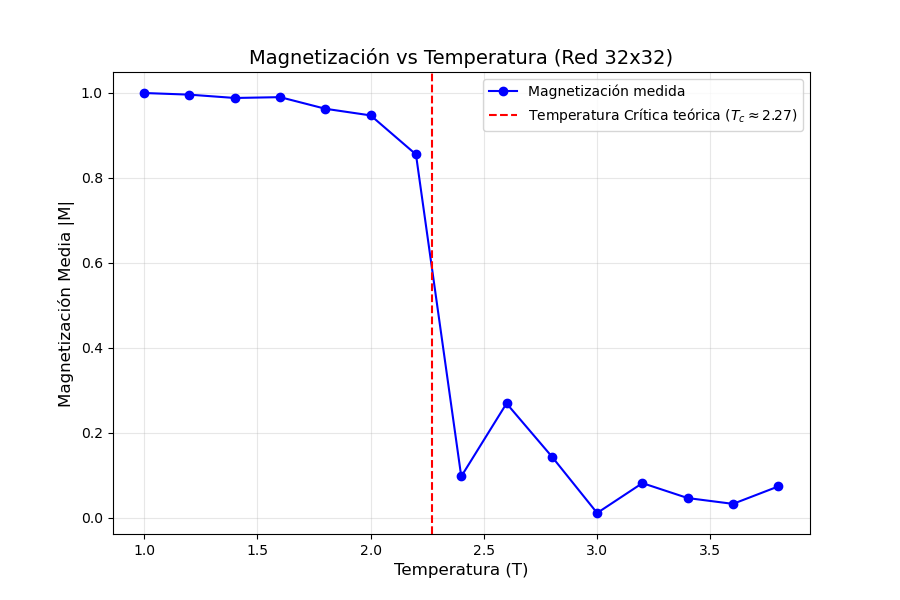

In [4]:
from IPython.display import Image
display(Image("grafica_magnetizacion.png"))

### Análisis de la gráfica:
Tras ejecutar la simulación para el barrido de temperaturas, la gráfica resultante muestra perfectamente la transición de fase del sistema. He graficado la temperatura crítica teórica ($2.27$), calculada por Lars Onsager en 1944. He dividido el análisis en tres zonas clave:
1. **Fase de orden total (Estado Ferromagnético):** A bajas temperaturas ($T < 2.0$), la magnetización se mantiene pegada al 1.0. La energía de interacción es tan fuerte que el calor no consigue desordenarlos; el material es un imán perfecto.
2. **La Transición Crítica ($T_c$):** Al acercarme a la línea roja ($T \approx 2.27$), la magnetización cae de forma brusca. Mi simulación capta el momento exacto en que la agitación térmica vence a las fuerzas de alineación. Físicamente, el material está dejando de ser ferromagnético para pasar a ser paramagnético.
3. **Fase de desorden y efectos de tamaño finito (Estado Paramagnético):** Para temperaturas altas ($T > 2.5$), la magnetización se desploma hacia valores muy bajos. Los espines están tan agitados por el calor que apuntan de forma aleatoria, cancelándose unos con otros. Sin embargo, la curva no llega a ser un cero perfecto, sino que tiene unas fluctuaciones o "zigzag". Entiendo que esto es un efecto del tamaño finito de mi red: como solo tengo 1024 espines, estadísticamente siempre hay un pequeño exceso hacia un lado o hacia otro.

## Conclusión

La gráfica y las animaciones validan totalmente mi código de C++. Se ve claramente cómo el orden se rompe al calentar el sistema, pasando de una estructura sólida y organizada a un estado de ruido térmico total justo al cruzar la barrera de la temperatura crítica.